In [2]:
import os
import sys
current = os.path.dirname(os.path.realpath("Visualize_Pairwise_Matches.ipynb"))
parent = os.path.dirname(current)
sys.path.append(parent)
# from transformers import CLIPProcessor, CLIPModel
import torch
import torch.hub
import torchvision
from torchvision.models import resnet50
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import clip
from PIL import Image
import requests
import torch.hub
import time
import pickle
import math

from match_utils import matching, stats, proggan, nethook, dataset, loading, plotting, layers, models, visualize_pairwisematch

/anaconda/envs/shaders_rosetta/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda:3')

# 1. Load models

In [4]:
gan_mode = "styleganxl"
discr_mode = "dino_vits16"
discr_path = "/datadrive/shaden/project1/FeatureInversion/pretrained_models/dino_shaders_mixup.pth"
discr_modelname = "dinoshadersmixup"

if gan_mode != "biggan" and gan_mode != "styleganxl":
    classidx = None
else: 
    classidx = 0

In [5]:
discr, discr_layers = models.load_discr(discr_mode, device, discr_path)
gan, gan_layers = models.load_gan(gan_mode, device)
ganlayers, discrlayers = layers.get_layers(gan,
                                        gan_layers=gan_layers, 
                                        discr=discr, 
                                        discr_layers=discr_layers,
                                        gan_mode=gan_mode, 
                                        discr_mode=discr_mode, 
                                        device=device)



Loading custom weights from /datadrive/shaden/project1/FeatureInversion/pretrained_models/dino_shaders_mixup.pth...


Using cache found in /home/marhamil/.cache/torch/hub/facebookresearch_dino_main


Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "filtered_lrelu_plugin"... Done.


In [6]:
matches_dir = "/datadrive/shaden/project1/kevin/shaders_rosetta/matches/250724000907-7e6b1c-1939ea1-code/matches/styleganxl_dinoshadersmixup_cls0_1600"

# 2. Load tables

In [7]:
table, gan_stats, discr_stats = loading.load_stats(root=matches_dir, device=device)

Loading...


Done


In [8]:
table.shape

torch.Size([26434, 18432])

# 3. Compute matches

In [9]:
match_scores, _ = torch.max(table,1)

In [10]:
n = 5
_, top1_discr_per_gan = torch.topk(table,k=1,dim=1) # Gx1 
_, topn_gan_per_discr = torch.topk(table,k=n, dim=0) # 5xD

In [14]:
gan_match_units = []
discr_match_units = []

perfect_match_scores1= []

num_kmatches = 0 

for gan_unit in range(table.shape[0]):
    top1_discr = top1_discr_per_gan[gan_unit].item()
    topn_gan = topn_gan_per_discr[:, top1_discr]
    
    for top_gan_for_discr in topn_gan:
        if top_gan_for_discr == gan_unit: # G unit j contained in its top D's top5
            num_kmatches += 1
            discr_match_units.append(top1_discr)

            gan_match_units.append(gan_unit)
            perfect_match_scores1.append(table[gan_unit, top1_discr])
            break

print(len(gan_match_units))

348


#### Sort units according to scores

In [18]:
# Sort both lists by perfect_match_scores1 in descending order
sorted_pairs = sorted(zip(perfect_match_scores1, gan_match_units), reverse=True)

gan_match_units = [match for score, match in sorted_pairs]
scores = [score.item() for score, _ in sorted_pairs]

# 4. Visualize Matches over Sample Images

In [16]:
batch_size = 1
epochs = 1
classidx = None
z_dataset, c_dataset = dataset.create_dataset(gan, gan_mode, batch_size, epochs, classidx, device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


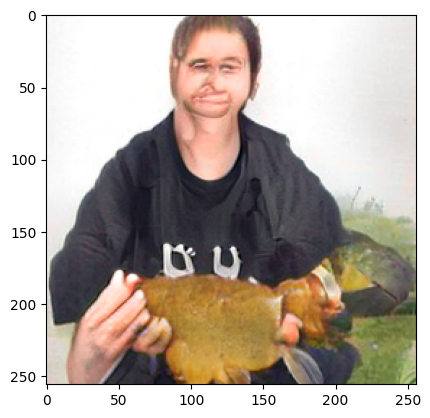

In [17]:
init = gan(z_dataset,c_dataset,1)
init = (init.detach().cpu()+1)/2
init = torch.permute(init[0], (1,2,0))
plt.imshow(init)
init = (init-torch.min(init))/(torch.max(init)-torch.min(init))
init = np.uint8(init*255)

In [20]:
num_units_to_viz = 2

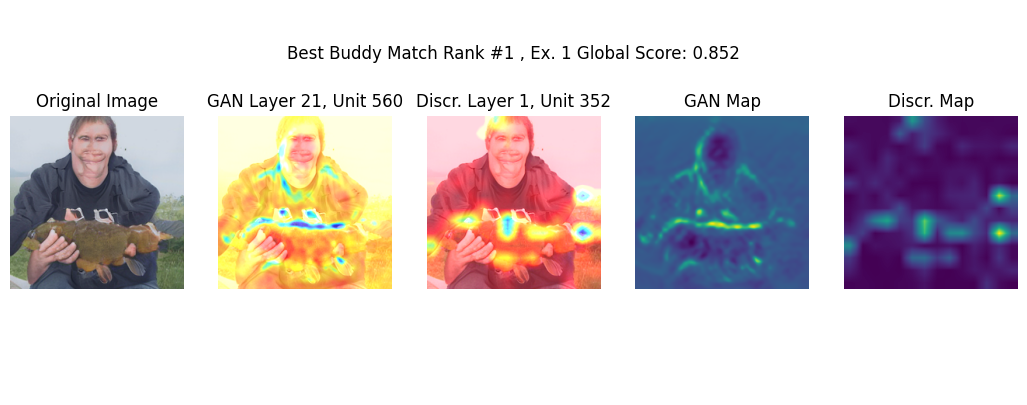

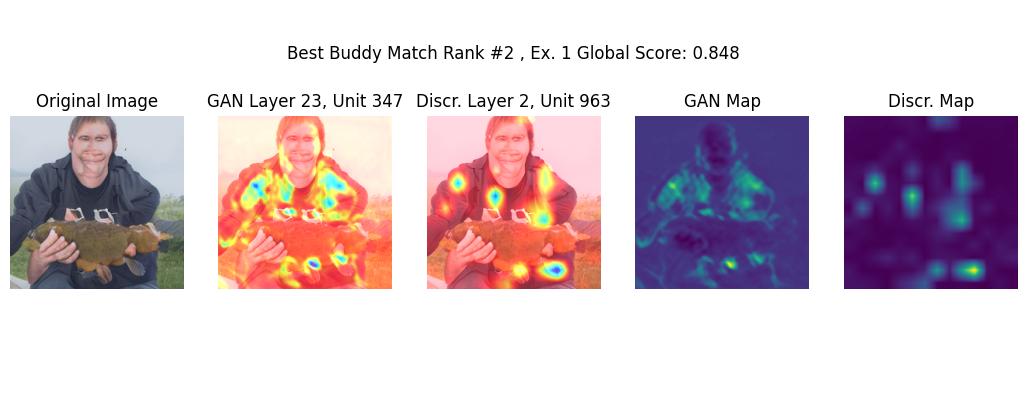

In [21]:
visualize_pairwisematch.viz_matches(table, gan, discr, (z_dataset,c_dataset), ganlayers, discrlayers, gan_stats, discr_stats, gan_mode, discr_mode, gan_match_units[:num_units_to_viz], scores[:num_units_to_viz])